In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from src import mobi

In [2]:
color1 = "#ff5f69"
color2 = "#bfd2ef"

In [3]:
def get_data(performance_dir):
    df1 = pd.read_csv(performance_dir+"/DREME_top5.txt", sep="\t", header=None)
    df2 = pd.read_csv(performance_dir+"/HOMER_top5.txt", sep="\t", header=None)
    df3 = pd.read_csv(performance_dir+"/MEME_top5.txt", sep="\t", header=None)

    plt_data_mean_hit = (df1.mean()[0], df1.mean()[1], df2.mean()[0], df2.mean()[1], df3.mean()[0], df3.mean()[1])
    plt_data_sem_hit = (df1.sem()[0], df1.sem()[1], df2.sem()[0], df2.sem()[1], df3.sem()[0], df3.sem()[1])
    plt_data_mean_known = (df1.mean()[5], df1.mean()[6], df2.mean()[5], df2.mean()[6], df3.mean()[5], df3.mean()[6])

    return((plt_data_mean_hit, plt_data_sem_hit, plt_data_mean_known))

In [4]:
def plt_ax_trim(ax_i):
    """
    From sns.utils -> despine function -> trim parameter
    See https://github.com/mwaskom/seaborn/blob/master/seaborn/utils.py
    """
    xticks = ax_i.get_xticks()
    if xticks.size:
        firsttick = np.compress(xticks >= min(ax_i.get_xlim()),
                                xticks)[0]
        lasttick = np.compress(xticks <= max(ax_i.get_xlim()),
                               xticks)[-1]
        ax_i.spines['bottom'].set_bounds(firsttick, lasttick)
        ax_i.spines['top'].set_bounds(firsttick, lasttick)
        newticks = xticks.compress(xticks <= lasttick)
        newticks = newticks.compress(newticks >= firsttick)
        ax_i.set_xticks(newticks)

    yticks = ax_i.get_yticks()
    if yticks.size:
        firsttick = np.compress(yticks >= min(ax_i.get_ylim()),
                                yticks)[0]
        lasttick = np.compress(yticks <= max(ax_i.get_ylim()),
                               yticks)[-1]
        ax_i.spines['left'].set_bounds(firsttick, lasttick)
        ax_i.spines['right'].set_bounds(firsttick, lasttick)
        newticks = yticks.compress(yticks <= lasttick)
        newticks = newticks.compress(newticks >= firsttick)
        ax_i.set_yticks(newticks)

In [5]:
def plt_bar(ax, m1, sem1=None, yticks=None):
    ax.bar([0,0.55, 1.75,2.3, 3.5,4.05], 
       m1,
       width=0.55,
       color=[color1, color2],
       linewidth=0.3,
       edgecolor="black",
       align="edge")

    if sem1:
        _, caps, sticks = ax.errorbar(
            x=np.array([0,0.55, 1.75,2.3, 3.5,4.05])+0.275, 
            y=m1,
            yerr=sem1,
            fmt=".", lw=1, capsize=1, markersize=0, elinewidth=0.5, ecolor=(0.1, 0.1, 0.1, 0.75))
        for cap in caps:
             cap.set_markeredgewidth(0.5)

    ax.set_xlim([-0.5, 5.05])
    ax.xaxis.set_ticks([0.575, 2.325, 4.075]) # limit x range        
    ax.xaxis.set_ticklabels(["DREME", "HOMER", "MEME"], fontsize=4)
    ax.xaxis.set_tick_params(size=0, pad=1)

    # y axis
    ax.spines["left"].set_linewidth(0.5) # axis width
    ax.yaxis.set_ticks(yticks) # limit y range
    ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f')) # use %.2f for number in yticklabels
    ax.yaxis.set_tick_params(size=2, width=0.6, pad=0, labelsize=4)
    

    # trim axis
    plt_ax_trim(ax)
    # no frame border
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    return(ax)

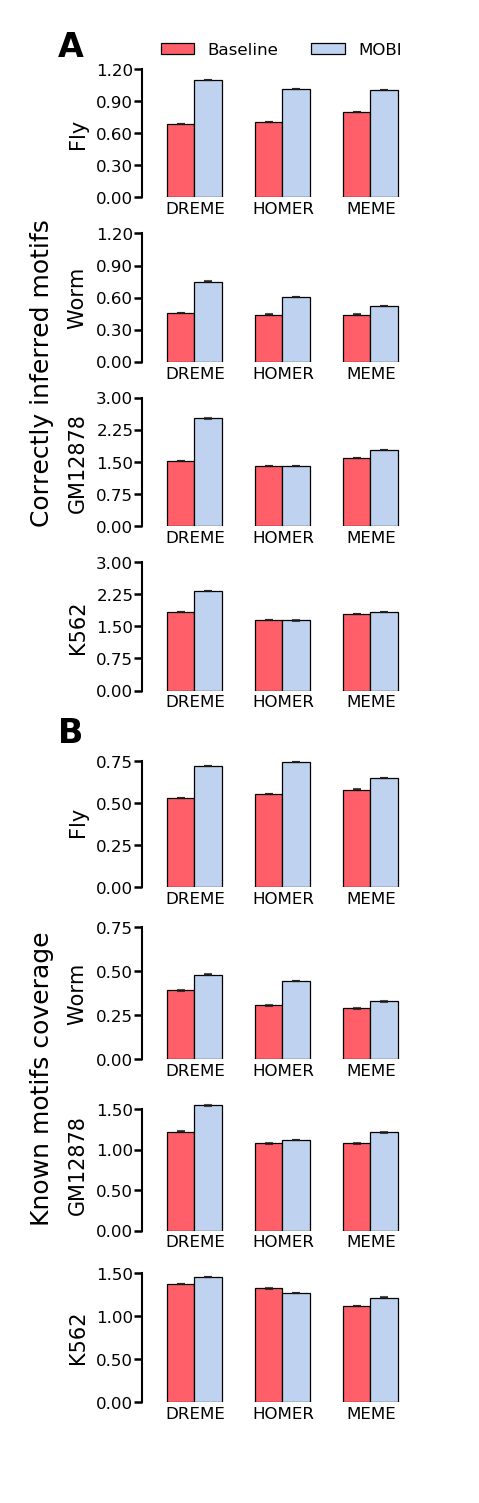

In [6]:
#sns.set_style("darkgrid", {'grid.linestyle': '--'})
sns.set_context("paper")

fig, axs = plt.subplots(
    nrows=2, ncols=1,
    gridspec_kw={'hspace': 0.1},
    figsize=(1.2, 6), dpi=300)

axs[0].axis('off')
axs[1].axis('off')

axs[0].annotate("Correctly inferred motifs", xy=(-0.4, 0.7), rotation=90, xycoords="axes fraction", fontsize=6)
axs[1].annotate("Known motifs coverage", xy=(-0.4, 0.7), rotation=90, xycoords="axes fraction", fontsize=6)

################
gs = mpl.gridspec.GridSpecFromSubplotSpec(9, 1, subplot_spec=axs[0], hspace=0, height_ratios=[0.1,0.1, 1,0.28, 1,0.28, 1,0.28, 1])

####
ax = fig.add_subplot(gs[2, 0])
m1, sem1, m2 = get_data("/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/fly/performance")
plt_bar(ax, m1, sem1, [0,0.3,0.6,0.9,1.2])
ax.set_ylabel("Fly", fontsize=5, labelpad=2)

ax.text(-0.3, 1.1, "A", transform=ax.transAxes, size=8, weight='bold')

####
ax = fig.add_subplot(gs[4, 0])
m1, sem1, m2 = get_data("/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/worm/performance")
plt_bar(ax, m1, sem1, [0,0.3,0.6,0.9,1.2])
ax.set_ylabel("Worm", fontsize=5, labelpad=2)

####
ax = fig.add_subplot(gs[6, 0])
m1, sem1, m2 = get_data("/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/humanGM12878/performance")
plt_bar(ax, m1, sem1, [0,0.75,1.5,2.25,3])
ax.set_ylabel("GM12878", fontsize=5, labelpad=2)

####
ax = fig.add_subplot(gs[8, 0])
m1, sem1, m2 = get_data("/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/humanK562/performance")
plt_bar(ax, m1, sem1, [0,0.75,1.5,2.25,3])
ax.set_ylabel("K562", fontsize=5, labelpad=2)

####
ax = plt.gca()
patches = ax.patches
ax_cbar = fig.add_subplot(gs[0, 0])
ax_cbar.set_axis_off()
ax_cbar.legend(patches, ["Baseline", "MOBI"], loc="center", ncol=2, fontsize=4, frameon=False)

################
gs = mpl.gridspec.GridSpecFromSubplotSpec(4, 1, subplot_spec=axs[1], hspace=0.3)

####
ax = fig.add_subplot(gs[0, 0])
m1, sem1, m2 = get_data("/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/fly/performance")
plt_bar(ax, m2, sem1, yticks=[0,0.25,0.5,0.75])
ax.set_ylabel("Fly", fontsize=5, labelpad=2)

ax.text(-0.3, 1.1, "B", transform=ax.transAxes, size=8, weight='bold')

####
ax = fig.add_subplot(gs[1, 0])
m1, sem1, m2 = get_data("/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/worm/performance")
plt_bar(ax, m2, sem1, yticks=[0,0.25,0.5,0.75])
ax.set_ylabel("Worm", fontsize=5, labelpad=2)

####
ax = fig.add_subplot(gs[2, 0])
m1, sem1, m2 = get_data("/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/humanGM12878/performance")
plt_bar(ax, m2, sem1, yticks=[0,0.5,1,1.5])
ax.set_ylabel("GM12878", fontsize=5, labelpad=2)

####
ax = fig.add_subplot(gs[3, 0])
m1, sem1, m2 = get_data("/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/humanK562/performance")
plt_bar(ax, m2, sem1, yticks=[0,0.5,1,1.5])
ax.set_ylabel("K562", fontsize=5, labelpad=2)

# plt.show()
plt.savefig("./fig5.pdf", dpi="figure", bbox_inches="tight")